# 29. Data Visualization Project

## Proje Tanıtımı

Bu projede veri görselleştirme çalışması yapılacaktır.

Veri görselleştirme, veri setindeki örüntüleri, dağılımları ve ilişkileri daha anlaşılır hale getirmek için kullanılır.  
Bu projede Iris veri seti kullanılacak ve farklı grafik türleri ile veri seti incelenecektir.

Bu çalışma bir makine öğrenmesi modelinden çok, keşifsel veri analizi ve görselleştirme odaklıdır.

## Proje Yol Haritası

1. Gerekli kütüphanelerin içe aktarılması  
2. Iris veri setinin yüklenmesi  
3. Veri setinin tabloya dönüştürülmesi  
4. Veri setinin genel yapısının incelenmesi  
5. Sınıf dağılımının görselleştirilmesi  
6. Özellik dağılımlarının incelenmesi  
7. Özellikler arası ilişkilerin görselleştirilmesi  
8. Korelasyon analizinin yapılması  
9. Görselleştirme sonuçlarının yorumlanması  
10. README ve requirements dosyalarının oluşturulması  
11. Proje dosyalarının kontrol edilmesi  
12. Proje sonucunun yazılması

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## Veri Setinin Yüklenmesi

Bu adımda Scikit-learn kütüphanesi içinden Iris veri setini yüklüyoruz.

Iris veri seti, üç farklı çiçek türüne ait ölçümlerden oluşur.  
Bu projede veri setini grafiklerle inceleyerek sınıflar ve özellikler arasındaki ilişkileri anlamaya çalışacağız.

In [2]:
# Iris veri setini yüklüyor ve tabloya çeviriyoruz
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Veri Setinin İncelenmesi

Bu adımda veri setinin genel yapısını kontrol ediyoruz.

Önce satır-sütun sayısına, veri tiplerine ve eksik değer olup olmadığına bakacağız.  
Bu kontrol, görselleştirme yapmadan önce veri setini tanımamızı sağlar.

In [3]:
# Veri setinin satır ve sütun sayısını kontrol ediyoruz
df.shape

(150, 5)

In [4]:
# Eksik değer olup olmadığını kontrol ediyoruz
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## Temel İstatistikler

Bu adımda sayısal değişkenlerin temel istatistiklerini inceliyoruz.

Ortalama, standart sapma, minimum ve maksimum değerler; veri setindeki ölçümlerin genel dağılımı hakkında bilgi verir.

In [5]:
# Sayısal değişkenlerin temel istatistiklerini inceliyoruz
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Sınıf Dağılımının Görselleştirilmesi

Bu adımda Iris veri setindeki çiçek türlerinin dağılımını inceliyoruz.

Sınıf dağılımı, veri setinde her sınıftan kaç örnek olduğunu gösterir.  
Dengeli bir veri setinde sınıfların örnek sayıları birbirine yakın olur.

In [6]:
# Iris türlerinin dağılımını kontrol ediyoruz
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

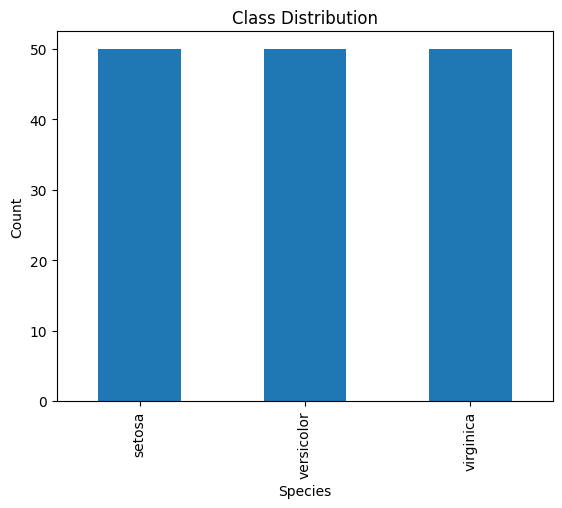

In [7]:
# Iris türlerinin dağılımını sütun grafiği ile gösteriyoruz
df["species"].value_counts().plot(kind="bar")
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

## Sınıf Dağılımı Yorumu

Grafikte Iris veri setindeki üç çiçek türünün eşit sayıda örneğe sahip olduğu görülmektedir.

Bu durum, veri setinin sınıf dağılımı açısından dengeli olduğunu gösterir.  
Dengeli veri setleri, analiz ve modelleme aşamalarında daha sağlıklı sonuçlar elde etmeye yardımcı olur.

## Özellik Dağılımlarının İncelenmesi

Bu adımda Iris veri setindeki sayısal özelliklerin dağılımlarını inceliyoruz.

Dağılım grafikleri, her değişkenin hangi değer aralıklarında yoğunlaştığını gösterir.  
Bu sayede çiçek ölçümlerinin genel yapısı daha kolay anlaşılır.

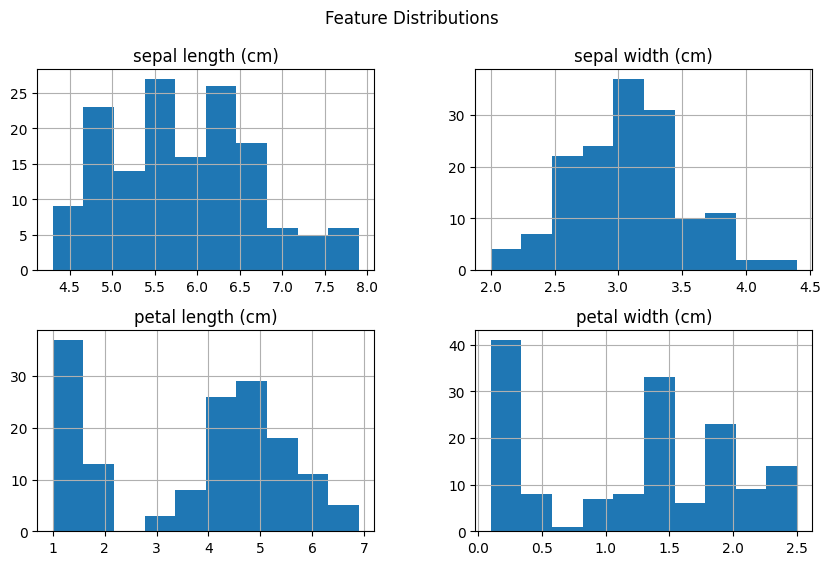

In [8]:
# Sayısal özelliklerin dağılımlarını histogram ile gösteriyoruz
df.drop("species", axis=1).hist(figsize=(10, 6))
plt.suptitle("Feature Distributions")
plt.show()

## Dağılım Grafikleri Yorumu

Histogram grafiklerinde her sayısal özelliğin değer dağılımı görülmektedir.

Bazı özelliklerde değerler belirli aralıklarda yoğunlaşırken, bazı özelliklerde dağılım daha geniştir.  
Özellikle petal length ve petal width değişkenleri, çiçek türlerini ayırmada daha belirgin olabilir.

## Türlere Göre Özellik Dağılımları

Bu adımda çiçek türlerine göre sayısal özelliklerin nasıl değiştiğini inceliyoruz.

Boxplot grafikleri, her tür için ölçümlerin dağılımını, ortanca değerini ve uç değerleri göstermeye yardımcı olur.

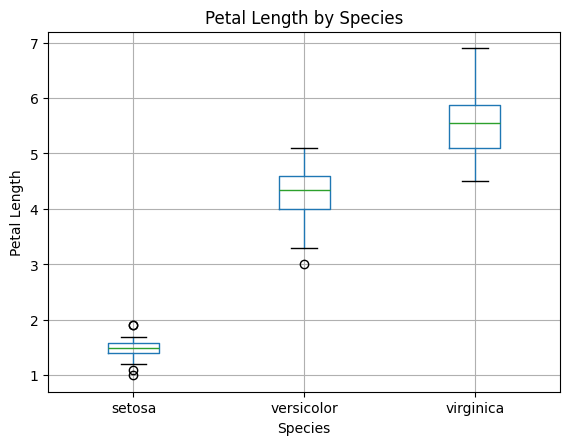

In [9]:
# Türlere göre petal length dağılımını boxplot ile gösteriyoruz
df.boxplot(column="petal length (cm)", by="species")
plt.title("Petal Length by Species")
plt.suptitle("")
plt.xlabel("Species")
plt.ylabel("Petal Length")
plt.show()

## Özellikler Arası İlişkilerin Görselleştirilmesi

Bu adımda Iris veri setindeki sayısal özellikler arasındaki ilişkileri inceliyoruz.

Scatter plot grafikleri, iki değişken arasındaki ilişkiyi görmemizi sağlar.  
Özellikle petal length ve petal width değişkenleri tür ayrımında önemli olabilir.

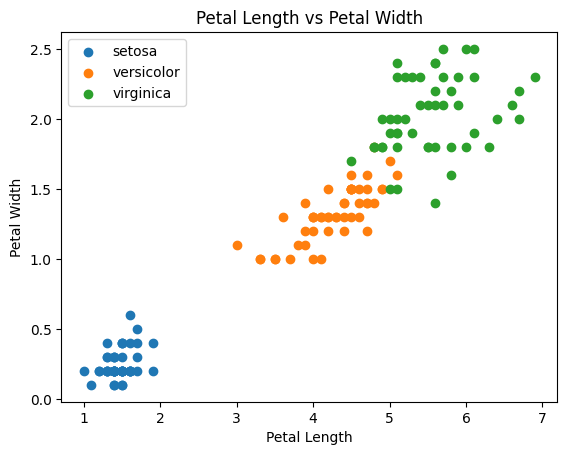

In [10]:
# Petal length ve petal width ilişkisini türlere göre görselleştiriyoruz
for species in df["species"].unique():
    temp = df[df["species"] == species]
    plt.scatter(temp["petal length (cm)"], temp["petal width (cm)"], label=species)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.show()

## Scatter Plot Yorumu

Grafikte petal length ve petal width değişkenlerinin çiçek türlerini ayırmada oldukça etkili olduğu görülmektedir.

Özellikle setosa türü diğer türlerden daha net ayrılmaktadır.  
Versicolor ve virginica türleri ise bazı bölgelerde birbirine daha yakın görünmektedir.

## Çoklu Özellik İlişkileri

Bu adımda veri setindeki sayısal değişkenlerin birbirleriyle olan ilişkilerini toplu olarak inceliyoruz.

Scatter matrix grafiği, birden fazla değişken arasındaki ilişkileri aynı anda görmemizi sağlar.

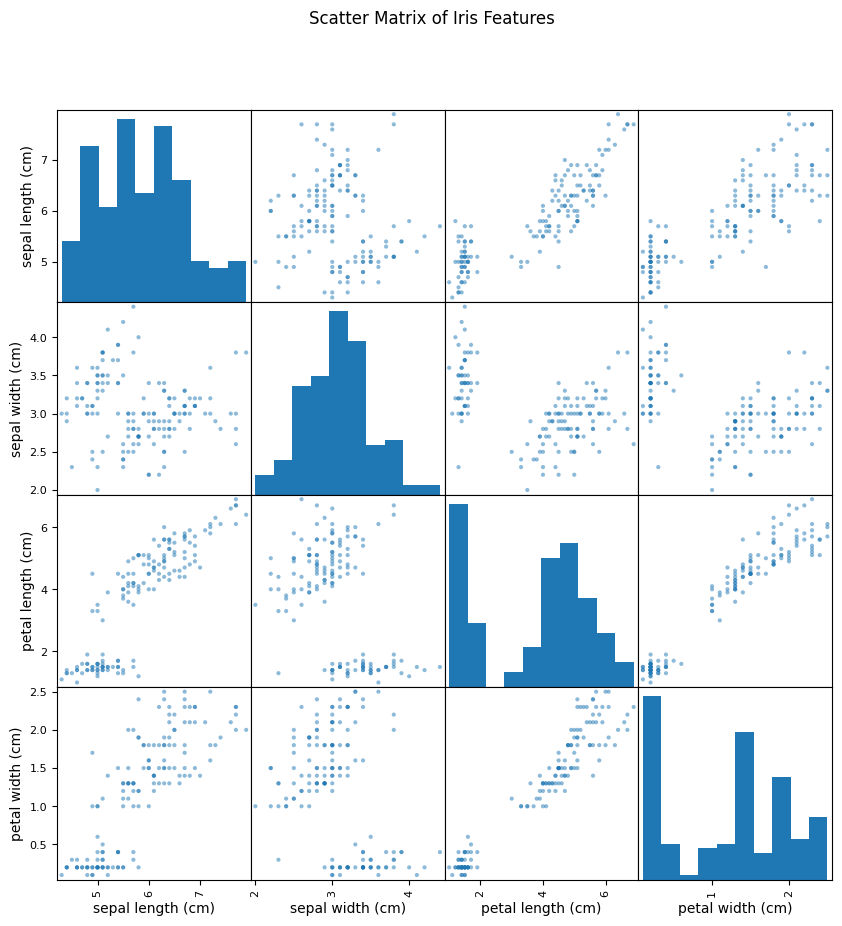

In [11]:
# Sayısal değişkenler arasındaki ilişkileri toplu olarak görselleştiriyoruz
pd.plotting.scatter_matrix(df.drop("species", axis=1), figsize=(10, 10), diagonal="hist")
plt.suptitle("Scatter Matrix of Iris Features")
plt.show()

## Korelasyon Analizi

Bu adımda sayısal değişkenler arasındaki korelasyon ilişkilerini inceliyoruz.

Korelasyon, iki değişkenin birlikte nasıl hareket ettiğini gösterir.  
Pozitif korelasyon, iki değişkenin birlikte arttığını; negatif korelasyon ise biri artarken diğerinin azaldığını ifade eder.

Bu analiz, Iris veri setinde hangi özelliklerin birbirleriyle daha güçlü ilişkili olduğunu anlamamıza yardımcı olur.

In [12]:
# Sayısal değişkenler arasındaki korelasyonu hesaplıyoruz
corr = df.drop("species", axis=1).corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


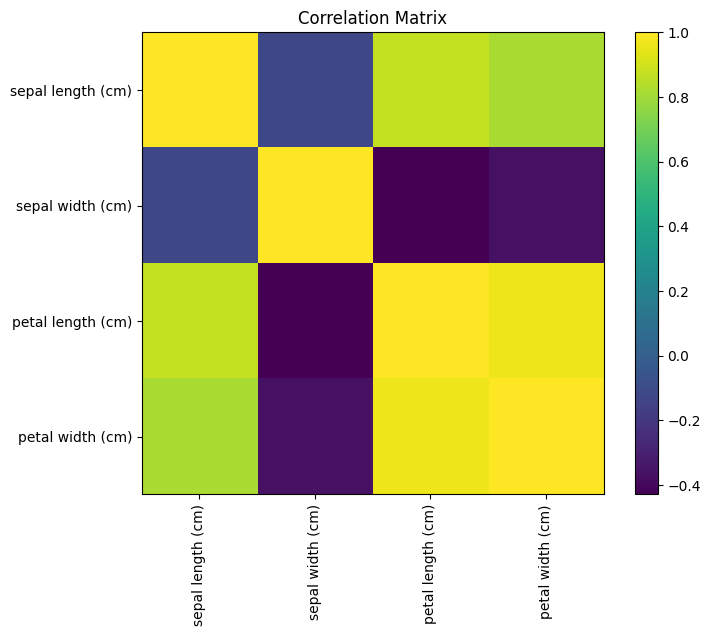

In [13]:
# Korelasyon matrisini heatmap olarak görselleştiriyoruz
plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Korelasyon Yorumu

Korelasyon analizinde özellikle petal length ve petal width değişkenleri arasında güçlü bir ilişki olduğu görülmektedir.

Bu sonuç, petal ölçümlerinin Iris türlerini ayırmada önemli olabileceğini destekler.  
Sepal değişkenleri de veri seti hakkında bilgi verir ancak tür ayrımında petal değişkenleri kadar belirgin olmayabilir.

## Streamlit Uygulamasının Oluşturulması

Bu proje bir model eğitimi projesi değil, veri görselleştirme projesidir.

Bu nedenle kaydedilecek bir makine öğrenmesi modeli bulunmamaktadır.  
Ancak projeyi çevrim içi sunabilmek için Iris veri setini görselleştiren basit bir Streamlit uygulaması oluşturulacaktır.

In [14]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in iris.target]

st.title("Iris Data Visualization Project")
st.write("This app visualizes the Iris dataset using simple charts.")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Class Distribution")
fig1, ax1 = plt.subplots()
df["species"].value_counts().plot(kind="bar", ax=ax1)
ax1.set_xlabel("Species")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution")
st.pyplot(fig1)

st.subheader("Petal Length vs Petal Width")
fig2, ax2 = plt.subplots()
for species in df["species"].unique():
    temp = df[df["species"] == species]
    ax2.scatter(temp["petal length (cm)"], temp["petal width (cm)"], label=species)
ax2.set_xlabel("Petal Length")
ax2.set_ylabel("Petal Width")
ax2.set_title("Petal Length vs Petal Width")
ax2.legend()
st.pyplot(fig2)

st.subheader("Correlation Matrix")
corr = df.drop("species", axis=1).corr()
fig3, ax3 = plt.subplots()
im = ax3.imshow(corr)
fig3.colorbar(im)
ax3.set_xticks(range(len(corr.columns)))
ax3.set_yticks(range(len(corr.columns)))
ax3.set_xticklabels(corr.columns, rotation=90)
ax3.set_yticklabels(corr.columns)
ax3.set_title("Correlation Matrix")
st.pyplot(fig3)

Writing app.py


## Requirements Dosyasının Oluşturulması

Bu adımda Streamlit uygulamasının çalışması için gerekli kütüphaneleri requirements.txt dosyasına yazıyoruz.

Bu dosya Hugging Face Spaces veya GitHub üzerinde uygulamanın çalıştırılması için gereklidir.

In [15]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
scikit-learn

Writing requirements.txt


## README Dosyasının Oluşturulması

Bu adımda proje için README.md dosyası oluşturuyoruz.

README dosyası; projenin amacını, kullanılan veri setini, yapılan görselleştirmeleri ve Streamlit uygulamasının nasıl çalıştığını açıklar.

In [16]:
%%writefile README.md
# Data Visualization Project

## Project Description

This project focuses on data visualization using the Iris dataset.

The aim is to explore the dataset through charts and understand class distribution, feature distributions, relationships between variables, and correlations.

## Dataset

The Iris dataset contains measurements of three flower species:

- Setosa
- Versicolor
- Virginica

The numerical features are:

- Sepal length
- Sepal width
- Petal length
- Petal width

## Visualizations

The project includes the following visualizations:

1. Class distribution bar chart
2. Feature distribution histograms
3. Boxplot by species
4. Scatter plot of petal length and petal width
5. Scatter matrix
6. Correlation matrix heatmap

## Streamlit App

A Streamlit app was created to visualize the Iris dataset interactively.

The app includes:

- Dataset preview
- Class distribution chart
- Petal length vs petal width scatter plot
- Correlation matrix

## Note

This project is a data visualization project. Therefore, no machine learning model was trained or saved.

## Conclusion

The visualizations show that petal length and petal width are strong features for separating Iris species.

The Setosa species is clearly separated from the others, while Versicolor and Virginica show some overlap.

Writing README.md


## Proje Dosyalarının Kontrol Edilmesi

Bu adımda proje için gerekli dosyaların oluşup oluşmadığını kontrol ediyoruz.

Bu proje bir model eğitimi projesi olmadığı için model dosyası yoktur.  
Ancak Streamlit uygulaması, requirements dosyası ve README dosyası eksiksiz olmalıdır.

In [17]:
# Proje dosyalarının eksiksiz oluşup oluşmadığını kontrol ediyoruz
import os

required = [
    "app.py",
    "requirements.txt",
    "README.md"
]

missing = [f for f in required if not os.path.exists(f)]

"All files are ready." if not missing else f"Missing files: {missing}"

'All files are ready.'

## Proje Sonucu

Bu projede Iris veri seti üzerinde veri görselleştirme çalışması yapılmıştır.

İlk olarak veri seti yüklenmiş ve tablo haline getirilmiştir.  
Daha sonra veri setinin genel yapısı, eksik değer durumu ve temel istatistikleri incelenmiştir.

Sınıf dağılımı bar grafiği ile gösterilmiş ve veri setindeki üç çiçek türünün dengeli olduğu görülmüştür.  
Histogram grafiklerle sayısal özelliklerin dağılımları incelenmiştir.

Boxplot, scatter plot ve scatter matrix grafikleri kullanılarak özellikler arasındaki ilişkiler analiz edilmiştir.  
Özellikle petal length ve petal width değişkenlerinin tür ayrımında önemli olduğu görülmüştür.

Son olarak korelasyon matrisi oluşturulmuş ve değişkenler arasındaki ilişkiler incelenmiştir.  
Bu proje, veri görselleştirmenin veri setini anlamada ne kadar önemli olduğunu göstermektedir.

Proje sonunda Streamlit uygulaması, requirements.txt ve README.md dosyaları oluşturulmuştur.